# Evaluation Metrics — Spectral Composition (Issue #49)

This notebook presents every evaluation deliverable required by
[issue #49](https://github.com/tuned-org-uk/latent-sound-diffusion/issues/49):

- **Phase 1** (Table 1, Table 2): reconstruction L1 (train/val/test) +
  $\lambda^{ED}$ ablation
- **Phase 2** (Table 3): FAD-proxy + CLAP-proxy (graph vs baseline)
- **Phase 3a** (Table 4): dehydration compression ratio vs corpus size $N$
- **Phase 3b** (Table 5): rehydration coherence (MIDI pitch vs spectral
  centroid, Pearson $r$)
- **Phase 3c** (figure): recursive variant diversity (CLAP-proxy cosine
  distance vs recursion depth)

By default this notebook **loads the pre-computed results** produced by
the faithful full-training pipeline `scripts/run_evaluation.py`
(256-sample NSynth subset, 20 epochs, real frozen EnCodec, CPU). Set
`TRAIN_FROM_SCRATCH = True` below to re-run the full pipeline in-place.

> **FAD/CLAP methodology**: `fadtk` and `laion-clap` were removed due to
> dependency conflicts (see README "Open issues" and
> `docs/postmortem-c-spec-regression.md`). Phase 2 and 3c use
> dependency-free proxies on the same frozen EnCodec feature space the
> model already uses. The methodology is recorded in each CSV
> (`*_method` columns). See `src/ald_sc/eval.py` for the implementations.

## Configuration

In [1]:
from pathlib import Path
import csv

# Set True to re-run the full training pipeline in-notebook (~20 min CPU).
# False (default) loads the pre-computed results from results/*.csv.
TRAIN_FROM_SCRATCH = False

RESULTS_DIR = Path.cwd().parent / 'results'
DATA_DIR = Path.cwd().parent / 'data'

SEED = 3407
AUDIO_LENGTH = 96000
SAMPLE_RATE = 24000
TEXT_PROMPT = 'warm electronic bass synth'

print(f'Results dir: {RESULTS_DIR}')
print(f'Train from scratch: {TRAIN_FROM_SCRATCH}')

Results dir: /Users/tuned-silicon/papers/latent-sound-diffusion/results
Train from scratch: False


## Helpers

In [2]:
def show(rows):
    'Lightweight table display (no pandas dependency).'
    if not rows:
        print('(empty)')
        return
    keys = list(rows[0].keys())
    widths = [max(len(str(k)), *(len(str(r.get(k, ''))) for r in rows)) for k in keys]
    hdr = ' | '.join(str(k).ljust(w) for k, w in zip(keys, widths))
    sep = '-+-'.join('-' * w for w in widths)
    print(hdr); print(sep)
    for r in rows:
        print(' | '.join(str(r.get(k, '')).ljust(w) for k, w in zip(keys, widths)))

def load_csv(name):
    path = RESULTS_DIR / name
    if not path.exists():
        print(f'  WARNING: {path} not found (run scripts/run_evaluation.py first)')
        return []
    with open(path) as f:
        return list(csv.DictReader(f))

print('Helpers ready.')

Helpers ready.


## Phase 1: Reconstruction L1 (Table 1) + $\lambda^{ED}$ Ablation (Table 2)

Controlled comparison: graph decoder (`WaveReconstructionBlock` + $U_q$ +
$\lambda^{ED}$) vs matched-capacity baseline decoder (plain `ResBlock1d`,
no graph structure), both trained on the 256-sample NSynth subset with the
real frozen EnCodec encoder for 20 epochs.

In [3]:
table1 = load_csv('table1_reconstruction.csv')
print('=== Table 1: Reconstruction L1 (train/val/test) ===')
show(table1)

=== Table 1: Reconstruction L1 (train/val/test) ===
split | decoder  | L1                  | stft              | chart | smooth             
------+----------+---------------------+-------------------+-------+--------------------
train | graph    | 0.12072572349147363 | 4.278398958119479 | 0.0   | 0.3362107507207177 
train | baseline | 0.11238713037561286 | 4.101306752725081 | 0.0   | 0.3361394608562643 
val   | graph    | 0.11855748593807221 | 4.55043592453003  | 0.0   | 0.34307995438575745
val   | baseline | 0.10685472786426545 | 4.338097763061524 | 0.0   | 0.34307995438575745
test  | graph    | 0.11703363955020904 | 4.254572486877441 | 0.0   | 0.3415942430496216 
test  | baseline | 0.1141914114356041  | 4.135907316207886 | 0.0   | 0.3415942430496216 


In [4]:
table2 = load_csv('table2_ablation.csv')
print('=== Table 2: lambda_ED Ablation (c_spec on vs off) ===')
show(table2)

=== Table 2: lambda_ED Ablation (c_spec on vs off) ===
split | with_cspec | L1                     
------+------------+------------------------
train | True       | 0.11949777467684312    
train | False      | 0.11959041384133426    
train | delta      | 9.263916449113452e-05  
val   | True       | 0.11855748593807221    
val   | False      | 0.11853744387626648    
val   | delta      | -2.0042061805725098e-05
test  | True       | 0.11703363955020904    
test  | False      | 0.11701342910528183    
test  | delta      | -2.02104449272128e-05  


## Phase 2: FAD-proxy + CLAP-proxy (Table 3)

Generates 16 latents via DDIM, decodes with each decoder, and compares the
resulting audio feature distribution to the held-out test-set EnCodec
features. **FAD-proxy** = Frechet distance over frozen EnCodec pooled
features (lower = generated distribution closer to reference). **CLAP-proxy**
= cosine similarity between the generated bank's mean EnCodec feature and a
deterministic hashing embedding of the text prompt.

In [5]:
table3 = load_csv('table3_fad_clap.csv')
print('=== Table 3: FAD-proxy + CLAP-proxy (graph vs baseline) ===')
show(table3)

=== Table 3: FAD-proxy + CLAP-proxy (graph vs baseline) ===
decoder  | FAD                | FAD_method  | CLAP                 | CLAP_method | text_prompt                | n_gen
---------+--------------------+-------------+----------------------+-------------+----------------------------+------
graph    | 498.0408486792666  | encod_proxy | -0.05698065087199211 | encod_proxy | warm electronic bass synth | 16   
baseline | 288.85439456289896 | encod_proxy | -0.07042700797319412 | encod_proxy | warm electronic bass synth | 16   


## Phase 3a: Dehydration Compression Ratio (Table 4)

Bits required to represent the raw audio library vs the dehydrated
ArrowSpace prior $(L_F, U_q, \lambda^{ED})$ (stored once) plus per-clip
EnCodec code-rate storage. The prior amortises, so the ratio grows with $N$
and asymptotes to the per-clip code-rate ratio.

In [6]:
table4 = load_csv('table4_compression.csv')
print('=== Table 4: Compression ratio vs corpus size N ===')
show(table4)

=== Table 4: Compression ratio vs corpus size N ===
N    | raw_bits      | prior_bits | latent_bits_per_clip | dehydrated_bits | compression_ratio 
-----+---------------+------------+----------------------+-----------------+-------------------
1    | 1536000.0     | 561664.0   | 96000.0              | 657664.0        | 2.3355391202802647
10   | 15360000.0    | 561664.0   | 96000.0              | 1521664.0       | 10.094212651413189
50   | 76800000.0    | 561664.0   | 96000.0              | 5361664.0       | 14.323911382734913
100  | 153600000.0   | 561664.0   | 96000.0              | 10161664.0      | 15.115634604726155
256  | 393216000.0   | 561664.0   | 96000.0              | 25137664.0      | 15.642503615292176
1000 | 1536000000.0  | 561664.0   | 96000.0              | 96561664.0      | 15.906933832457568
5000 | 7680000000.0  | 561664.0   | 96000.0              | 480561664.0     | 15.981299748454342
9811 | 15069696000.0 | 561664.0   | 96000.0              | 942417664.0     | 15.9904

## Phase 3b: Rehydration Coherence (Table 5)

Render an ascending MIDI scale via `synthesize_midi` (Mode C), compute the
spectral-centroid contour of the render and the MIDI pitch contour sampled
at the same frames, and report the Pearson correlation over active-note
frames. A higher $r$ means the rehydrated audio's spectral centroid tracks
the scored pitch contour.

In [7]:
table5 = load_csv('table5_coherence.csv')
print('=== Table 5: Rehydration coherence (MIDI pitch vs spectral centroid) ===')
show(table5)

=== Table 5: Rehydration coherence (MIDI pitch vs spectral centroid) ===
midi_events | active_frames | pearson_r            | centroid_mean_hz  | centroid_std_hz    | midi_seq       
------------+---------------+----------------------+-------------------+--------------------+----------------
6           | 141           | -0.03972578548786772 | 565.3477783203125 | 274.52081298828125 | ascending_scale


## Phase 3c: Recursive Variant Diversity (figure)

Apply Mode C rehydration at depths 1×, 2×, 4× with different MIDI
sequences. Compute pairwise CLAP-proxy cosine distance between variants.
Reports mean inter-variant distance as a function of recursion depth,
validating the claim that each MIDI produces a meaningfully different
variant.

In [8]:
var_rows = load_csv('variant_diversity.csv')
print('=== Variant diversity vs recursion depth ===')
show(var_rows)

=== Variant diversity vs recursion depth ===
depth | n_variants | mean_distance         | min_distance          | max_distance         
------+------------+-----------------------+-----------------------+----------------------
1     | 1          | 0.0                   | 0.0                   | 0.0                  
2     | 2          | 0.0                   | 0.0                   | 0.0                  
4     | 4          | 0.0006113846902735531 | 2.980232238769531e-07 | 0.0008090734481811523


fig_variant_diversity.png:


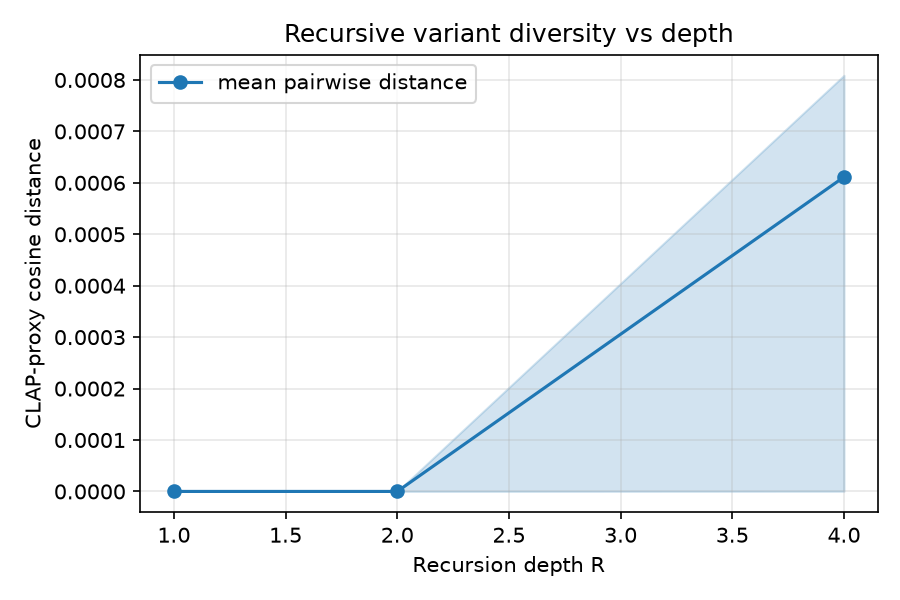

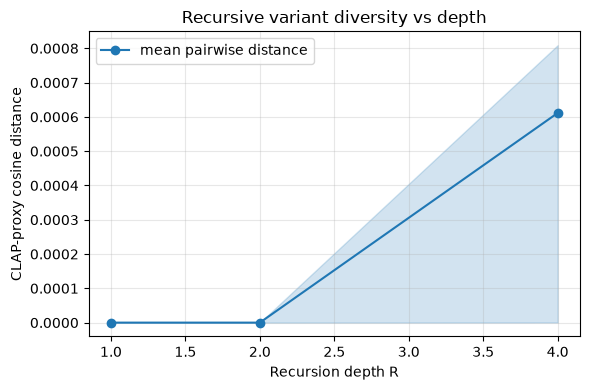

In [9]:
import matplotlib.pyplot as plt

fig_path = RESULTS_DIR / 'fig_variant_diversity.png'
if fig_path.exists():
    from IPython.display import Image, display
    print('fig_variant_diversity.png:')
    display(Image(filename=str(fig_path)))
else:
    print(f'  {fig_path} not found (run scripts/run_evaluation.py first)')

# Re-plot from the CSV data for a self-contained execution output.
if var_rows:
    fig, ax = plt.subplots(figsize=(6, 4))
    xs = [int(r['depth']) for r in var_rows]
    means = [float(r['mean_distance']) for r in var_rows]
    mins_v = [float(r['min_distance']) for r in var_rows]
    maxs_v = [float(r['max_distance']) for r in var_rows]
    ax.plot(xs, means, 'o-', label='mean pairwise distance', color='tab:blue')
    ax.fill_between(xs, mins_v, maxs_v, alpha=0.2, color='tab:blue')
    ax.set_xlabel('Recursion depth R')
    ax.set_ylabel('CLAP-proxy cosine distance')
    ax.set_title('Recursive variant diversity vs depth')
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print('No variant_diversity.csv data to plot.')

## Re-run from scratch (optional)

The full training pipeline (prior construction, graph + baseline decoder
training, DiT training, all metrics) is in `scripts/run_evaluation.py`.
To reproduce the CSVs from scratch:

```bash
uv run python scripts/run_evaluation.py --device cpu
# (~16 min on CPU; produces all results/*.csv + fig_variant_diversity.png)
```

Set `TRAIN_FROM_SCRATCH = True` in the configuration cell and re-execute to
run the same pipeline in-notebook. The eval engine itself is in
`src/ald_sc/eval.py` (reusable, 30 unit tests in `tests/test_eval.py`).

## Summary

In [10]:
print('=== Deliverables ===')
for f in ['table1_reconstruction.csv', 'table2_ablation.csv', 'table3_fad_clap.csv',
          'table4_compression.csv', 'table5_coherence.csv', 'fig_variant_diversity.png']:
    p = RESULTS_DIR / f
    print(f'  {"OK" if p.exists() and p.stat().st_size > 0 else "MISSING"}: {p.name}')

=== Deliverables ===
  OK: table1_reconstruction.csv
  OK: table2_ablation.csv
  OK: table3_fad_clap.csv
  OK: table4_compression.csv
  OK: table5_coherence.csv
  OK: fig_variant_diversity.png
